# EUROPEAN CALL OPTION WITH MONTE CARLO

In [45]:
from matplotlib import pyplot as plt
import numpy as np
import scipy


In [46]:

def paths(S0, r, q, sig, T, M, N):
    """(N, M+1) array of GBM paths, exact stepping, antithetic."""
    dt = T/M
    Z = np.random.randn(N//2, M)
    Z = np.concatenate([Z, -Z], axis=0)
    incr = (r - q - 0.5*sig**2)*dt + sig*np.sqrt(dt)*Z

    logS = np.zeros((N, M+1))
    logS[:, 0]  = np.log(S0)
    logS[:, 1:] = np.log(S0) + np.cumsum(incr, axis=1)
    S = np.exp(logS)

    return S


def price(S_at_T, K, r, T): #S_at_T will be the last column of all the walkers S[:, -1]
    v = np.exp(-r*T)*np.maximum(S_at_T - K, 0)
    return v.mean(), v.std(ddof=1)/np.sqrt(len(v))

In [54]:
T = 1.
S0 = 1.
r = 0.03
sigma = 0.20
q = 0.01
K = 1.

In [55]:

#array for number of samples
N = np.array([100,500,1000,5000,10000,50000,100000,500000,1000000])

In [56]:
european_call_payoffs = np.zeros((len(N),2))

for i in range(0, len(N)):
    european_call_payoffs[i,:] = price(paths(S0, r, q, sigma, T, 10, N[i])[:, -1], K,  r, T)

In [57]:
def euro_call(x, tau, K, r, q, sig):
   
    d2 = (x + (r - 0.5*sig**2)*tau) / (sig*np.sqrt(tau))
    d1 = d2 + sig*np.sqrt(tau)
    return np.exp(-q*tau)*K*np.exp(x)*scipy.stats.norm.cdf(d1) - K*np.exp(-r*tau)*scipy.stats.norm.cdf(d2)

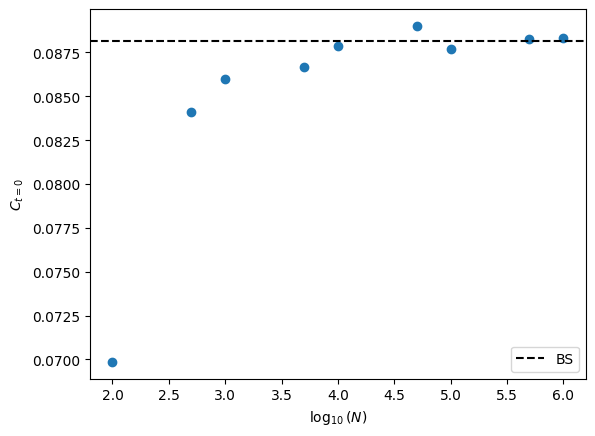

In [58]:
plt.scatter(np.log10(N), european_call_payoffs[:,0])
plt.axhline(y = euro_call(np.log(S0/K),T,K,r,q,sigma), c='black', linestyle='dashed', label ='BS')
plt.xlabel(r'$\log_{10}(N)$')
plt.ylabel(r'$C_{t=0}$')
plt.legend()
plt.show()

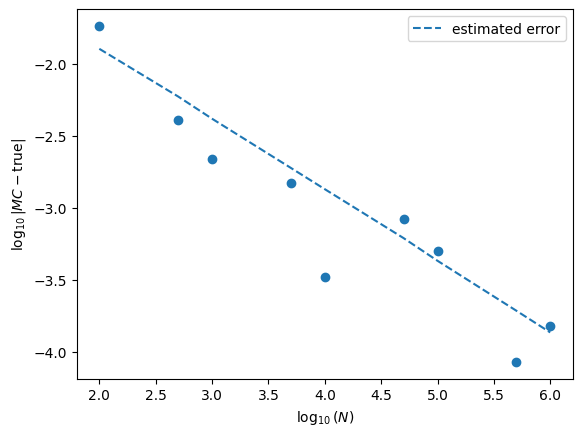

In [62]:
plt.scatter(np.log10(N), np.log10(np.abs(european_call_payoffs[:,0] - euro_call(np.log(S0/K),T,K,r,q,sigma))))
plt.plot(np.log10(N), np.log10(np.abs(european_call_payoffs[:,1])), label ='estimated error', linestyle='dashed')
plt.xlabel(r'$\log_{10}(N)$')
plt.ylabel(r'$\log_{10}|{MC-\text{true}}|$')
plt.legend()
plt.show()